# Essay Writer

<div style="text-align: center;"><img src="./assets/06-1-EssayWriter-flow.png" width="600"></div>

In [1]:
from dotenv import load_dotenv

_ = load_dotenv()

In [2]:
# pip install tavily-python

In [3]:
# pip install langgraph-checkpoint-sqlite

In [4]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List, Optional
import operator
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage

memory = MemorySaver()

In [5]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: Optional[List[str]]
    revision_number: int
    max_revisions: int

In [6]:
from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [7]:
import os
from tavily import TavilyClient

tavily = TavilyClient(api_key=os.environ.get("TAVILY_API_KEY"))

In [8]:
PLAN_PROMPT = """You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections."""

In [9]:
WRITER_PROMPT = """You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}"""

In [10]:
REFLECTION_PROMPT = """You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc."""

In [11]:
RESEARCH_PLAN_PROMPT = """You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max."""


In [12]:
RESEARCH_CRITIQUE_PROMPT = """You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max."""


In [13]:
from pydantic import BaseModel

class Queries(BaseModel):
    queries: List[str]

In [14]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [15]:
def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries, method='function_calling').invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state.get('content', [])
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [16]:
def generation_node(state: AgentState):
    content = "\n\n".join(state.get('content', []))
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
        ]
    response = model.invoke(messages)
    return {
        "draft": response.content, 
        "revision_number": state.get("revision_number", 1) + 1
    }


In [17]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT), 
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [18]:
def research_critique_node(state: AgentState):
    queries = model.with_structured_output(Queries, method='function_calling').invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state.get('content', [])
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

In [19]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [20]:
builder = StateGraph(AgentState)

In [21]:
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

In [22]:
builder.set_entry_point("planner")

In [23]:
builder.add_conditional_edges(
    "generate", 
    should_continue, 
    {END: END, "reflect": "reflect"}
)


In [24]:
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

In [25]:
graph = builder.compile(checkpointer=memory)

In [26]:
# pip install pygraphviz

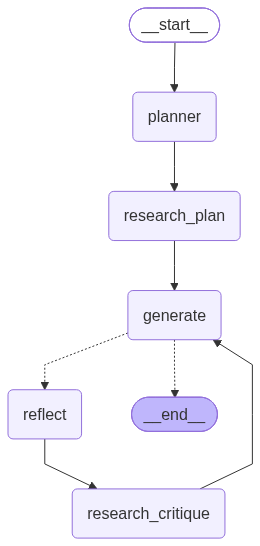

In [27]:
from IPython.display import Image

Image(graph.get_graph().draw_mermaid_png())

In [28]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
    'task': "what is the difference between langchain and langsmith",
    "max_revisions": 2,
    "revision_number": 1,
}, thread):
    print(s)

{'planner': {'plan': '### Essay Outline: The Difference Between LangChain and LangSmith\n\n#### I. Introduction\n   A. Definition of LangChain and LangSmith\n      1. Brief overview of what each tool is designed for\n      2. Importance of understanding the differences in the context of AI and language processing\n   B. Purpose of the essay\n      1. To compare and contrast LangChain and LangSmith\n      2. To provide insights into their respective use cases and functionalities\n\n#### II. Overview of LangChain\n   A. Description of LangChain\n      1. Purpose and primary functionalities\n      2. Key features (e.g., modularity, integration with language models)\n   B. Use Cases\n      1. Examples of applications in AI development\n      2. Industries or sectors that benefit from LangChain\n\n#### III. Overview of LangSmith\n   A. Description of LangSmith\n      1. Purpose and primary functionalities\n      2. Key features (e.g., user interface, analytics capabilities)\n   B. Use Cases

<div style="text-align: center;"><img src="./assets/06-2-EssayWriter-multi-agent.png" width="700"></div>

<div style="text-align: center;"><img src="./assets/06-3-EssayWriter-supervisor.png" width="700"></div>

<div style="text-align: center;"><img src="./assets/06-4-EssayWriter-plan-and-execute.png" width="700"></div>

<div style="text-align: center;"><img src="./assets/06-5-EssayWriter-language-agent-tree-search.png" width="700"></div>

## Essay Writer Interface

In [29]:
import warnings
warnings.filterwarnings("ignore")

from helper import ewriter, writer_gui

In [30]:
MultiAgent = ewriter()
app = writer_gui(MultiAgent.graph)
app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
